# The Ultimate Data Analysis Visualization Guide
Golden rule of Python visualization: Matplotlib is the canvas, Seaborn is the paint. 
Use Seaborn to draw the data because it understands Pandas DataFrames natively and calculates statistics (like confidence intervals) under the hood. Use Matplotlib to adjust the frame, the labels, the axes, and the canvas size.

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Build a synthetic HR dataset with:
- Continuous variables (age, salary)
- Discrete variables (tenure)
- Categorical variables (department)
- Binary outcomes (promotion)

Introduces:
- Controlled randomness
- Statistical realism
- Feature relationships

Suitable for:

- Data visualization
- Machine learning demos
- Exploratory data analysis (EDA)

In [2]:
# Set the global theme for all Seaborn/Matplotlib visualizations
# Adds a white background with gridlines, uses a muted color palette, and increases the font size for better readability
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# Let's enerate a realistic, messy dataset (for the needs of this guide)
np.random.seed(42)      # Reproducibility Setup
n = 2000        # Dataset Size
df = pd.DataFrame({
    # Generates n values from a normal distribution: mean of 35, standard deviation of 10, and clips values to be between 18 and 70
    'age': np.random.normal(35, 10, n).clip(18, 70), 

    # Generates random integers: between 1 and 120 to represent the number of months an employee has been with the company  
    'tenure_months': np.random.randint(1, 120, n),

    # Randomly assigns a department using: Probabilities (p=) 30% for Sales, 40% for Engineering, 10% for HR, and 20% for Marketing
    # Produces a categorical variable with weighted distribution.
    'department': np.random.choice(['Sales', 'Engineering', 'HR', 'Marketing'], n, p=[0.3, 0.4, 0.1, 0.2]),

    # Generates salaries from a normal distribution: mean of 75,000, standard deviation of 25,000, and creates a continuous variable with some variability.
    'salary': np.random.normal(75000, 25000, n),

    # Promotion Flag: Randomly assigns 0 (not promoted) or 1 (promoted) with probabilities of 85% and 15%, respectively, to create a binary variable indicating promotion status.
    'is_promoted': np.random.choice([0, 1], n, p=[0.85, 0.15])
})

# Add some realistic relationships and noise
# Engineering Salary Boost df.loc[condition, column] selects rows conditionally. Here, it selects rows where the 'department' is 'Engineering' and adds 20,000 to their 'salary'.
df.loc[df['department'] == 'Engineering', 'salary'] += 20000

# Promotion Salary Boost: Adds 15,000 to the 'salary' of employees who have been promoted (where 'is_promoted' == 1).
df.loc[df['is_promoted'] == 1, 'salary'] += 15000

# Derived Feature: Performance Score. Performance is loosely correlated with salary, but noisy. Mimics real-world imperfect metrics.
df['performance_score'] = (df['salary'] / 10000) + np.random.normal(0, 2, n)

## 1. Univariate Analysis: Understanding Single Features
### 1A. Numerical Features: apply the *histplot* for Continuous data (Salary, Age, Revenue)

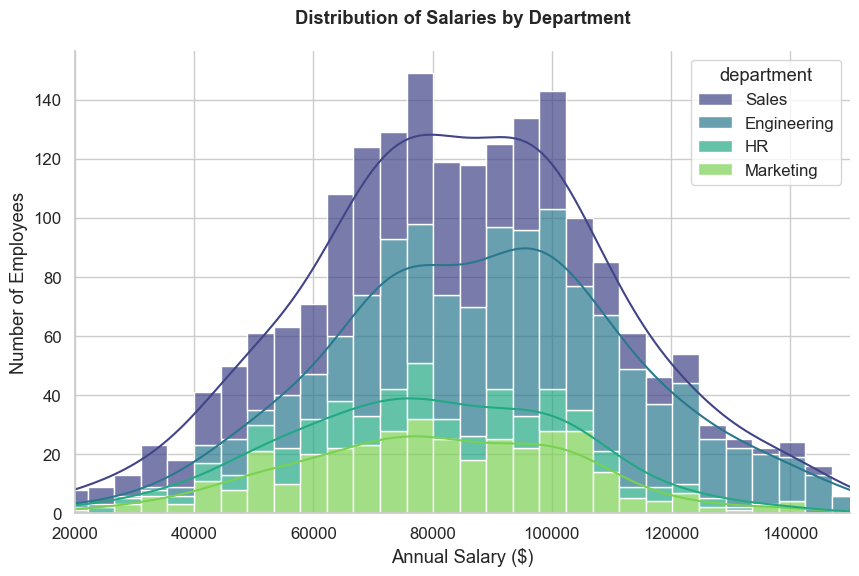

In [3]:
plt.figure(figsize=(10, 6)) # Step 1: Create the Matplotlib Canvas

# Step 2: The Seaborn Plot with advanced parameters
sns.histplot(
    data=df, 
    x='salary', 
    bins=40,               # Number of buckets. Play with this! Too few hides data, too many creates noise.
    kde=True,              # Kernel Density Estimate: Draws the smooth probability curve
    hue='department',      # Color by category. Brilliant for seeing overlapping distributions.
    multiple='stack',      # 'stack', 'dodge' (side-by-side), or 'layer' (overlapping with transparency)
    alpha=0.7,             # Transparency
    palette='viridis'      # Professional color mapping
)

# Step 3: Matplotlib Formatting
plt.title("Distribution of Salaries by Department", pad=20, fontweight='bold')
plt.xlabel("Annual Salary ($)")
plt.ylabel("Number of Employees")
plt.xlim(20000, 150000)    # Zoom in to ignore extreme outliers if necessary
sns.despine()              # Removes the top and right borders
plt.show()

### 1B. Categorical Features: use the *countplot* for Discrete/Categorical data (Department, Gender, Status).

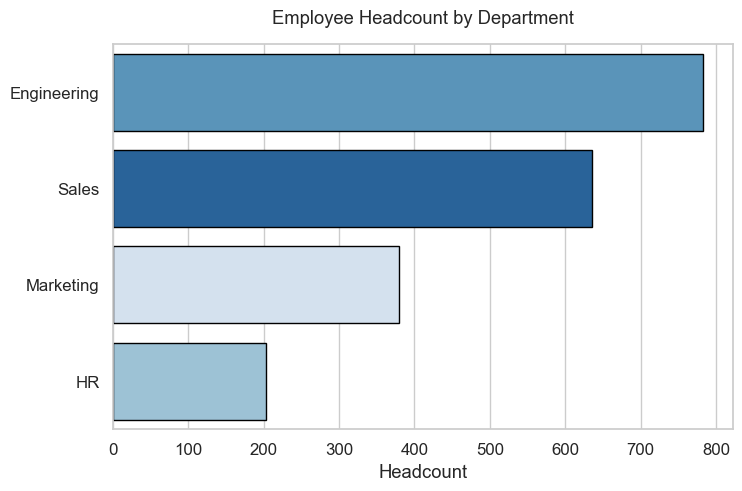

In [8]:
plt.figure(figsize=(8, 5))

# Order the bars by frequency (crucial for readability)
order = df['department'].value_counts().index

sns.countplot(
    data=df, 
    y='department',        # Using 'y' instead of 'x' makes it horizontal. Highly recommended for long text labels!
    order=order,           # Apply the sorting we defined above
    palette='Blues_r',     # _r reverses the colormap so the largest is darkest
    hue='department',
    legend=False,
    edgecolor='black'      # Adds a crisp border to the bars
)

plt.title("Employee Headcount by Department", pad=15)
plt.xlabel("Headcount")
plt.ylabel("")           # Leave blank, the labels are self-explanatory
plt.show()

## 2. Bivariate Analysis: Finding Relationships
Business Goal: “What drives performance? Do senior employees make more money?”
### 2A. Numerical vs. Numerical: Scatter & Jointplots
Use this to see how two continuous variables interact.

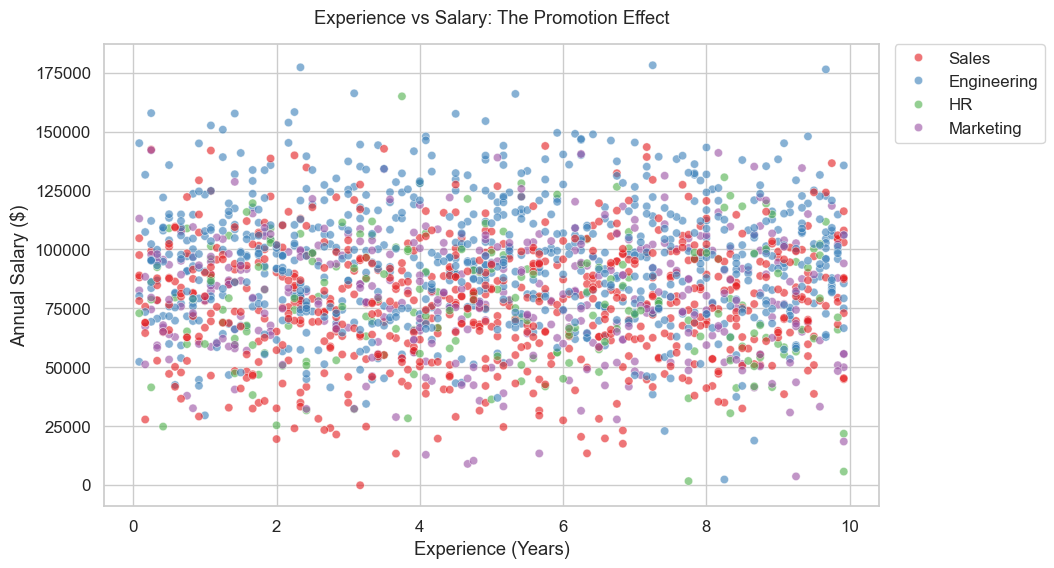

In [21]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x=df['tenure_months']/12,  # Convert to years for better interpretability
    y='salary', 
    hue='department',     # Adds a 3rd dimension (Categorical)
    # size='performance_score', # Adds a 4th dimension (Numerical - size of the dot)
    # sizes=(20, 200),       # Min and max size of the dots
    alpha=0.6,             # Crucial for overplotting
    palette='Set1'
)

# Move the complex legend completely outside the plot area
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.xlabel("Experience (Years)")
plt.ylabel("Annual Salary ($)")
plt.title("Experience vs Salary: The Promotion Effect", pad=15)
plt.show()

C:\Users\zahn\AppData\Local\Temp\ipykernel_9732\1024349403.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)


<Figure size 1000x600 with 0 Axes>

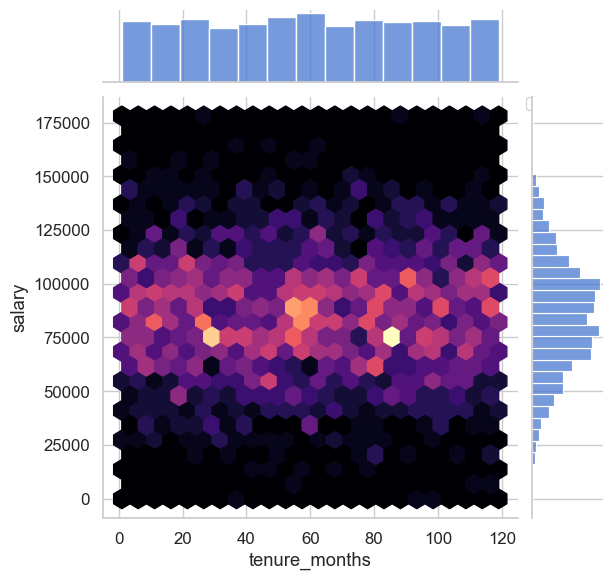

In [14]:
plt.figure(figsize=(10, 6))

sns.jointplot(
    data=df, 
    x='tenure_months', 
    y='salary', 
    kind='hex',
    cmap='magma'
)

# Move the complex legend completely outside the plot area
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.title("Tenure vs Salary: The Promotion Effect", pad=15)
plt.show()

### 2B. Categorical vs. Numerical: Box, Violin, and Strip
Use this to compare the distribution of a number across different groups.
“Does Engineering get paid more than Sales?”

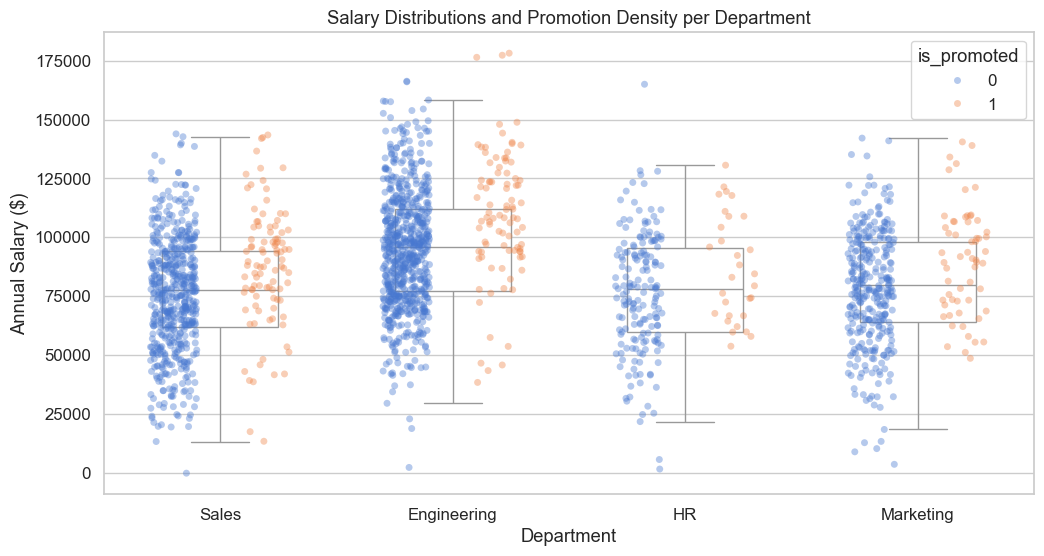

In [25]:
plt.figure(figsize=(12, 6))

# 1. The Boxplot gives the statistical summary (Median, IQR, Outliers)
sns.boxplot(
    data=df, 
    x='department', 
    y='salary', 
    showfliers=False,      # Hide outliers so they don't mix with the stripplot dots
    color='white',         # Keep the boxes clean
    width=0.5
)

# 2. The Stripplot overlays the ACTUAL data points to show volume
sns.stripplot(
    data=df, 
    x='department', 
    y='salary', 
    hue='is_promoted',     # See exactly where the promoted people sit in the distribution
    dodge=True,            # Separates the dots based on the hue! Very powerful.
    alpha=0.4, 
    jitter=0.2             # Spreads dots horizontally so they don't form a single vertical line
)

plt.title("Salary Distributions and Promotion Density per Department")
plt.ylabel("Annual Salary ($)")
plt.xlabel("Department")
plt.show()

## 3. Multivariate & Feature Engineering
Business Goal: “I have 20 numeric columns. I need to find the strongest predictors for employee salary immediately.”

### 3A. The Correlation Heatmap (The Right Way)
Use this to spot multicollinearity (features that mean the exact same thing) or target correlations.

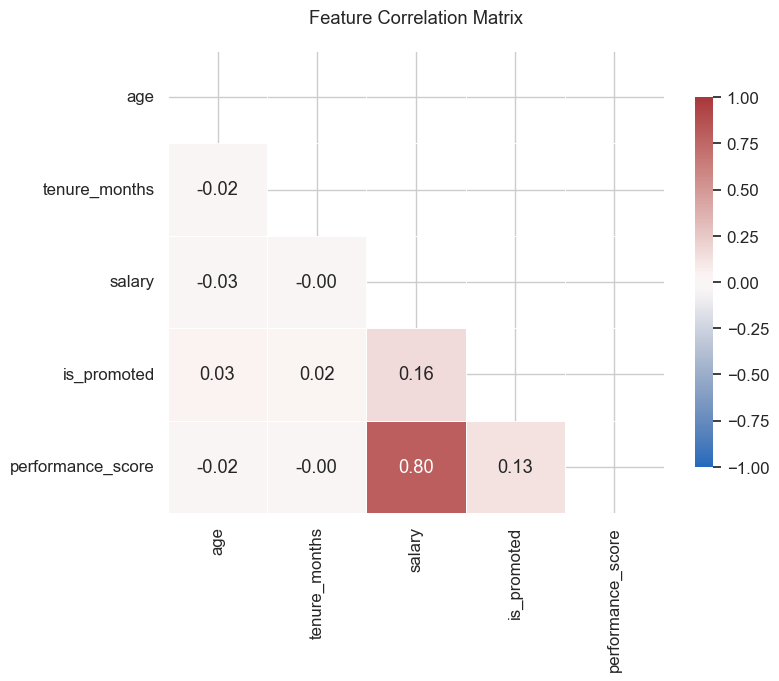

In [28]:
# Step 1: Isolate ONLY numerical columns (corr() will crash if you pass strings)
num_df = df.select_dtypes(include=[np.number])

# Step 2: Calculate Pearson correlation
corr_matrix = num_df.corr()

# Step 3: Create a mask for the upper triangle (removes redundant duplicate info)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Step 4: Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    mask=mask,             # Apply the triangle mask
    annot=True,            # Write the actual numbers in the squares
    fmt=".2f",             # Format numbers to 2 decimal places
    cmap='vlag',           # DIVERGING colormap (Blue for negative, Red for positive)
    vmin=-1, vmax=1,       # MUST hardcode these so the colors scale correctly!
    linewidths=0.5,        # Adds a grid line between squares
    cbar_kws={"shrink": .8} # Makes the colorbar slightly smaller than the graph
)

plt.title("Feature Correlation Matrix", pad=20)
plt.show()

### 3B. Multi-Plot Grids: FacetGrid (via catplot or relplot)

Use this when you want to recreate the exact same chart for different categories without writing a for loop.

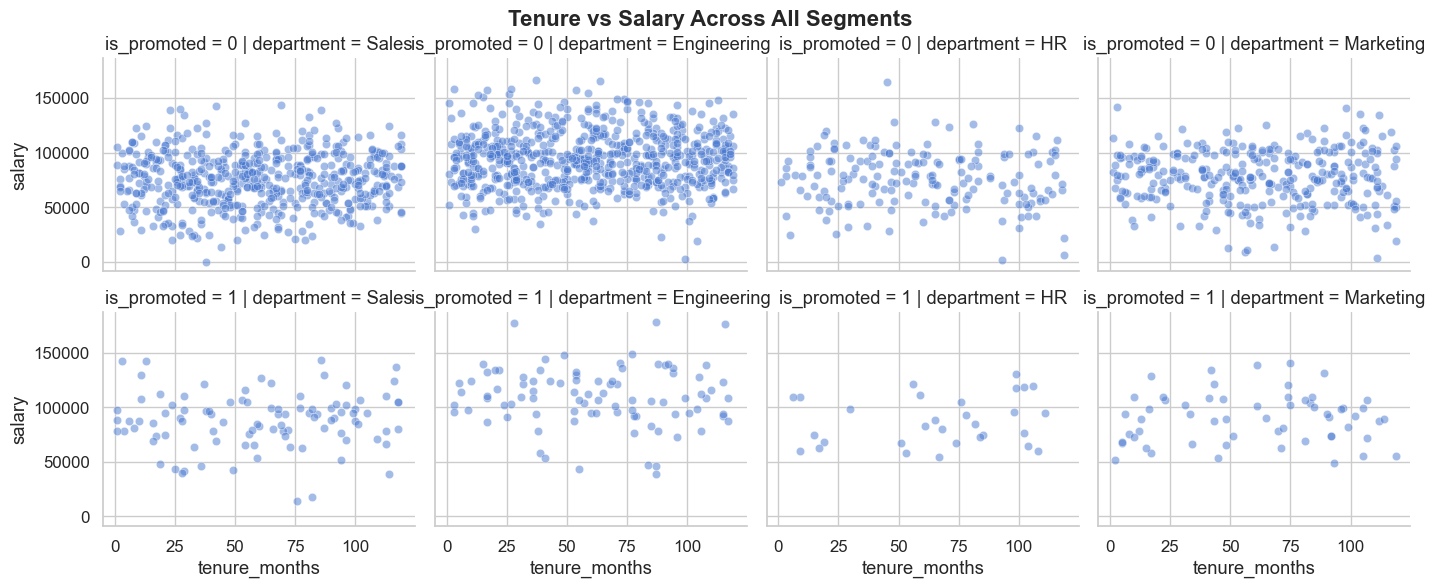

In [29]:
# We want to see the relationship between Tenure and Salary, but broken down 
# by Department AND by Promotion Status.

sns.relplot(
    data=df, 
    x='tenure_months', 
    y='salary', 
    col='department',      # Creates a new chart (column) for each department
    row='is_promoted',     # Creates a new row for promoted vs not promoted
    kind='scatter',        # Can be 'line' or 'scatter'
    alpha=0.5,
    height=3,              # Height of each individual chart
    aspect=1.2             # Width-to-height ratio of each chart
)

# Matplotlib formatting for FacetGrids is slightly different
plt.subplots_adjust(top=0.9) # Make room for the main title
plt.suptitle("Tenure vs Salary Across All Segments", fontsize=16, fontweight='bold')
plt.show()

## 4. The Matplotlib Formatting Cheatsheet
You’ve built the Seaborn plot, but the axes may overlap and the labels may not look good. Keep this block saved for the finishing touches.

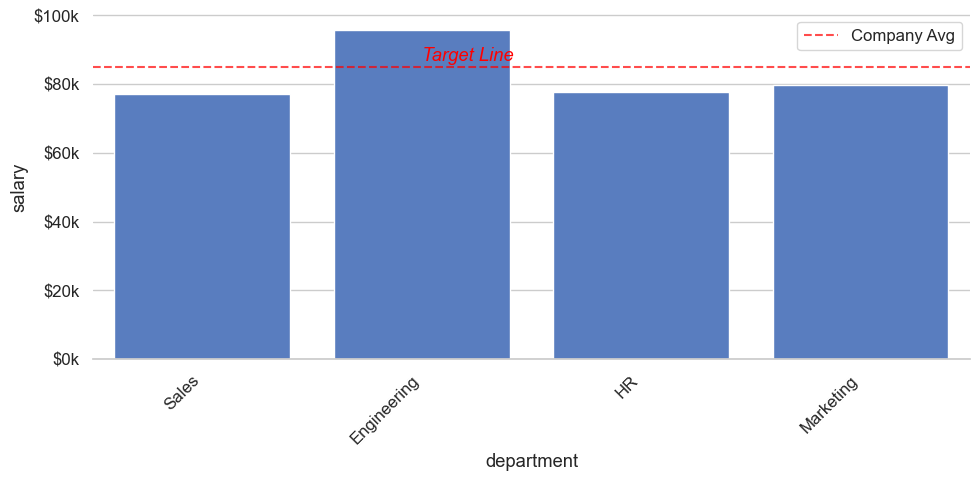

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df, x='department', y='salary', estimator=np.mean, errorbar=None, ax=ax)

# 1. Rotate X-Axis Labels (Crucial for long dates or text)
plt.xticks(rotation=45, ha='right') 

# 2. Format Y-Axis as Currency/Percentages
from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))

# 3. Add a horizontal line for a baseline/average
overall_mean = df['salary'].mean()
ax.axhline(overall_mean, color='red', linestyle='--', alpha=0.7, label='Company Avg')

# 4. Add direct text annotations to a specific point
ax.text(x=1, y=overall_mean + 2000, s="Target Line", color='red', fontstyle='italic')

# 5. Clean up the frame
sns.despine(left=True, bottom=False) # Removes left border, keeps bottom
ax.legend()
plt.tight_layout() # Magically prevents labels from getting cut off when saving the image
plt.show()